# Sprint 5 - Comparativo baseline vs actual, latencia y percepcion de usuario

**Tema:** Valores unitarios anomalos en exportaciones peruanas  
**Notebook:** `sprint5_comparativo_baseline_actual_latencia.ipynb`  
**Objetivo del avance:** comparar una linea base estable contra la version actual del analisis, medir latencia/capacidad, simular percepcion de usuario y dejar evidencia reproducible para la exposicion.

## Decision metodologica

- **Variable principal:** V.U. o valor unitario.
- **Unidad de analisis:** subpartida como slice independiente.
- **Baseline:** IQR por subpartida.
- **Version actual:** IQR + LOF + z-score, priorizando coincidencias de dos o mas metodos.
- **Universo de prueba:** top 5 subpartidas con mayor movimiento.
- **Feedback:** prueba guiada simulada para exposicion, no feedback real.

## Fuente metodologica de la clase

Rodriguez, G. (2026). *Prueba con stakeholder y latencia*. Proyecto de Investigacion 2. La clase solicita comparar baseline vs actual, medir p50/p95, throughput, errores, optimizaciones probadas, percepcion del usuario y recomendacion de despliegue minimo.


## 1. Instalacion opcional de dependencias

Ejecuta esta celda solo si tu ambiente no tiene las librerias necesarias.

```bash
pip install pandas numpy matplotlib scikit-learn openpyxl sqlalchemy pyodbc
```


In [1]:
# =============================================================================
# 1. CONFIGURACION GENERAL
# =============================================================================

from __future__ import annotations

import json
import math
import os
import time
import unicodedata
import warnings
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Callable
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.neighbors import LocalOutlierFactor
    from sklearn.preprocessing import RobustScaler
    SKLEARN_DISPONIBLE = True
except Exception:
    LocalOutlierFactor = None
    RobustScaler = None
    SKLEARN_DISPONIBLE = False

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Reproducibilidad
# -----------------------------------------------------------------------------
SEED = 42
RNG = np.random.default_rng(SEED)

# -----------------------------------------------------------------------------
# Modo de carga
# Opciones: DEMO, CSV, EXCEL, SQL_SERVER_SP, SQL_SERVER_QUERY
# -----------------------------------------------------------------------------
MODO_CARGA = "DEMO"
RUTA_ARCHIVO = Path(r"C:\Users\hp\Downloads\base_exportaciones.csv")
HOJA_EXCEL = 0

# -----------------------------------------------------------------------------
# Configuracion SQL Server
# Ajustar segun tu ambiente Windows.
# -----------------------------------------------------------------------------
SERVIDOR_SQL = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS_SQL = "DB_GEE_DW_ADUANAS"
ESQUEMA_SQL = "SC_ADUANA"
PROCEDIMIENTO_SQL = "SP_VALORES_UNITARIOS"
DRIVER_SQL = "ODBC Driver 17 for SQL Server"
FEC_INI = "2024-01-01"
FEC_FIN = "2024-12-31"

QUERY_SQL = f"""
SELECT
    NUM_PARTIDA, FEC_DECLARACION, MTO_FOBDOL, CNT_PESO_NETO, CNT_UNIFIS,
    COD_UNIFISICA, COD_ADUANA, SECTOR_NAME1, SECTOR_NAME2
FROM [DB_GEE_DW_ADUANAS].[SC_ADUANA].[BASE_EXPORTACIONES]
WHERE
    FEC_DECLARACION >= '{FEC_INI}'
    AND FEC_DECLARACION <= '{FEC_FIN}';
"""

# -----------------------------------------------------------------------------
# Columnas canonicas
# -----------------------------------------------------------------------------
COL_SUBPARTIDA = "subpartida"
COL_VALOR_UNITARIO = "valor_unitario"
COL_FOB = "fob_dolar"
COL_PESO_NETO = "peso_neto"
COL_CANTIDAD = "cantidad_exportada"
COL_UNIDAD_FISICA = "unidad_fisica"
COL_PAIS = "pais"
COL_OPERADOR = "operador"
COL_SECTOR = "sector"
COL_FECHA = "fecha"
COL_LOG_VU = "log_valor_unitario"

MAPEO_COLUMNAS_CANDIDATAS = {
    COL_SUBPARTIDA: [
        "subpartida", "num_partida", "num_partnandi", "num_spn_r", "partida",
        "partida_nandina", "part_nandi", "num_partnandi_codigo"
    ],
    COL_VALOR_UNITARIO: [
        "valor_unitario", "v_u", "vu", "mto_vu_unifis", "mto_vu_peso_neto",
        "valor_unitario_unifis", "valor_unitario_peso"
    ],
    COL_FOB: [
        "fob_dolar", "mto_fobdol", "mto_fob_dolar", "fob", "valor_fob", "mto_fob"
    ],
    COL_PESO_NETO: [
        "peso_neto", "cnt_peso_neto", "peso_neto_kg", "peso_kg"
    ],
    COL_CANTIDAD: [
        "cantidad_exportada", "cnt_unifis", "cantidad", "unidades", "cnt_comer"
    ],
    COL_UNIDAD_FISICA: [
        "unidad_fisica", "cod_unifisica", "cod_unifis", "des_unifisica", "cod_unicomer"
    ],
    COL_PAIS: [
        "pais", "pais_destino", "des_pais_destino", "cod_pais", "pais_origen"
    ],
    COL_OPERADOR: [
        "operador", "ruc_exportador", "num_ruc", "ruc", "exportador", "razon_social_exportador"
    ],
    COL_SECTOR: [
        "sector", "sector_name1", "sector_name2", "des_sector"
    ],
    COL_FECHA: [
        "fecha", "fec_declaracion", "fecha_declaracion", "fec_num", "fecha_exportacion"
    ],
}

# -----------------------------------------------------------------------------
# Parametros de negocio y estadistica
# -----------------------------------------------------------------------------
TOP_N_SUBPARTIDAS = 5
MIN_REGISTROS_SUBPARTIDA = 40
DEMO_ESCALA_REGISTROS = 0.20
UMBRAL_IQR = 1.5
UMBRAL_Z_SCORE = 3.0
CONTAMINACION_LOF = 0.05
VECINOS_LOF = 20
BOOTSTRAP_N = 300
REPETICIONES_LATENCIA = 3

# SLO propuesto para exposicion. Ajustalo si tu profesor o stakeholder define otro.
SLO_P95_SEGUNDOS = 5.0
SLO_ERROR_MAX_PCT = 1.0

# -----------------------------------------------------------------------------
# Artefactos
# Todos los CSV/TXT se exportan con delimitador pipe y sin acentos.
# -----------------------------------------------------------------------------
ARTIFACTS_DIR = Path("artifacts_sprint5_comparativo_latencia")
FIGURES_DIR = ARTIFACTS_DIR / "figuras"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuracion cargada.")
print(f"Modo de carga: {MODO_CARGA}")
print(f"Top subpartidas: {TOP_N_SUBPARTIDAS}")
print(f"Artefactos: {ARTIFACTS_DIR.resolve()}")
print(f"scikit-learn disponible: {SKLEARN_DISPONIBLE}")

Configuracion cargada.
Modo de carga: DEMO
Top subpartidas: 5
Artefactos: C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\06_Sprint5\artifacts_sprint5_comparativo_latencia
scikit-learn disponible: True


## 2. Funciones utilitarias

Estas funciones centralizan normalizacion, exportacion sin acentos, logs, intervalos de confianza y medicion de latencia.


In [2]:
# =============================================================================
# 2. FUNCIONES UTILITARIAS
# =============================================================================

@dataclass(frozen=True)
class ResultadoMedicion:
    """
    Representa una medicion agregada de latencia.

    Parameters
    ----------
    escenario : str
        Nombre del escenario de prueba.
    metodo : str
        Nombre del metodo evaluado.
    n_registros : int
        Cantidad de registros procesados.
    p50_segundos : float
        Percentil 50 de la latencia.
    p95_segundos : float
        Percentil 95 de la latencia.
    p99_segundos : float
        Percentil 99 de la latencia.
    promedio_segundos : float
        Tiempo promedio de ejecucion.
    minimo_segundos : float
        Tiempo minimo de ejecucion.
    maximo_segundos : float
        Tiempo maximo de ejecucion.
    throughput_registros_segundo : float
        Registros procesados por segundo.
    errores : int
        Cantidad de errores observados durante las repeticiones.
    observaciones : str
        Comentario tecnico de la medicion.

    Returns
    -------
    ResultadoMedicion
        Objeto inmutable con metricas de latencia.
    """
    escenario: str
    metodo: str
    n_registros: int
    p50_segundos: float
    p95_segundos: float
    p99_segundos: float
    promedio_segundos: float
    minimo_segundos: float
    maximo_segundos: float
    throughput_registros_segundo: float
    errores: int
    observaciones: str


def quitar_acentos(texto: Any) -> Any:
    """
    Elimina acentos de textos para exportaciones TXT/CSV.

    Parameters
    ----------
    texto : Any
        Valor original.

    Returns
    -------
    Any
        Texto sin acentos si el valor es str. En otro caso retorna el valor original.
    """
    if not isinstance(texto, str):
        return texto

    texto_normalizado = unicodedata.normalize("NFKD", texto)
    return "".join(caracter for caracter in texto_normalizado if not unicodedata.combining(caracter))


def preparar_dataframe_para_exportar(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepara un DataFrame para exportar con nombres y textos sin acentos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame original.

    Returns
    -------
    pd.DataFrame
        Copia del DataFrame sin acentos en columnas y campos texto.
    """
    df_export = df.copy()
    df_export.columns = [quitar_acentos(str(col)) for col in df_export.columns]

    for columna in df_export.select_dtypes(include=["object", "string"]).columns:
        df_export[columna] = df_export[columna].map(quitar_acentos)

    return df_export


def exportar_csv_pipe(df: pd.DataFrame, ruta: Path) -> None:
    """
    Exporta un DataFrame como CSV con delimitador pipe y sin acentos.

    Parameters
    ----------
    df : pd.DataFrame
        Tabla a exportar.
    ruta : Path
        Ruta de salida.

    Returns
    -------
    None
        Crea el archivo en disco.
    """
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df_export = preparar_dataframe_para_exportar(df)
    df_export.to_csv(ruta, sep="|", index=False, encoding="utf-8")


def exportar_txt_sin_acentos(texto: str, ruta: Path) -> None:
    """
    Exporta texto plano sin acentos.

    Parameters
    ----------
    texto : str
        Contenido a exportar.
    ruta : Path
        Ruta de salida.

    Returns
    -------
    None
        Crea el archivo en disco.
    """
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ruta.write_text(quitar_acentos(texto), encoding="utf-8")


def normalizar_nombre_columna(nombre: Any) -> str:
    """
    Normaliza nombres de columnas para busqueda robusta.

    Parameters
    ----------
    nombre : Any
        Nombre original de columna.

    Returns
    -------
    str
        Nombre en minusculas, sin acentos, sin espacios extras y con guion bajo.
    """
    texto = quitar_acentos(str(nombre)).strip().lower()
    texto = texto.replace(".", "_").replace("-", "_").replace(" ", "_")
    while "__" in texto:
        texto = texto.replace("__", "_")
    return texto


def buscar_columna(df: pd.DataFrame, candidatas: list[str]) -> str | None:
    """
    Busca una columna disponible a partir de nombres candidatos.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset original.
    candidatas : list[str]
        Lista de posibles nombres.

    Returns
    -------
    str | None
        Nombre real de la primera columna encontrada; None si no existe.
    """
    mapa = {normalizar_nombre_columna(col): col for col in df.columns}

    for candidata in candidatas:
        clave = normalizar_nombre_columna(candidata)
        if clave in mapa:
            return mapa[clave]

    return None


def convertir_numerico_seguro(serie: pd.Series) -> pd.Series:
    """
    Convierte valores a numerico controlando errores.

    Parameters
    ----------
    serie : pd.Series
        Serie original.

    Returns
    -------
    pd.Series
        Serie numerica con NaN si el valor no puede convertirse.
    """
    return pd.to_numeric(serie, errors="coerce")


def normalizar_serie(serie: pd.Series) -> pd.Series:
    """
    Normaliza una serie numerica entre 0 y 1.

    Parameters
    ----------
    serie : pd.Series
        Serie numerica.

    Returns
    -------
    pd.Series
        Serie normalizada. Si no hay rango, retorna ceros.
    """
    serie_num = pd.to_numeric(serie, errors="coerce").fillna(0.0)
    minimo = float(serie_num.min())
    maximo = float(serie_num.max())

    if not np.isfinite(minimo) or not np.isfinite(maximo) or math.isclose(maximo, minimo):
        return pd.Series(np.zeros(len(serie_num)), index=serie_num.index)

    return (serie_num - minimo) / (maximo - minimo)


def calcular_ic_bootstrap_mediana(
    valores: pd.Series,
    n_bootstrap: int = BOOTSTRAP_N,
    alpha: float = 0.05,
) -> tuple[float, float]:
    """
    Calcula intervalo de confianza bootstrap para la mediana.

    Parameters
    ----------
    valores : pd.Series
        Valores numericos del slice.
    n_bootstrap : int, default=BOOTSTRAP_N
        Numero de remuestreos bootstrap.
    alpha : float, default=0.05
        Nivel de significancia para IC 95%.

    Returns
    -------
    tuple[float, float]
        Limite inferior y superior del intervalo de confianza.
    """
    arr = pd.to_numeric(valores, errors="coerce").dropna().to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]

    if len(arr) < 5:
        return (np.nan, np.nan)

    medianas = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        muestra = RNG.choice(arr, size=len(arr), replace=True)
        medianas[i] = float(np.median(muestra))

    inferior = float(np.quantile(medianas, alpha / 2))
    superior = float(np.quantile(medianas, 1 - alpha / 2))
    return (inferior, superior)


def medir_funcion(
    funcion: Callable[[], Any],
    escenario: str,
    metodo: str,
    n_registros: int,
    repeticiones: int = REPETICIONES_LATENCIA,
) -> tuple[ResultadoMedicion, Any]:
    """
    Mide latencia repetible de una funcion.

    Parameters
    ----------
    funcion : Callable[[], Any]
        Funcion sin argumentos que ejecuta el pipeline a medir.
    escenario : str
        Nombre del escenario.
    metodo : str
        Nombre del metodo o variante.
    n_registros : int
        Cantidad de registros procesados.
    repeticiones : int, default=REPETICIONES_LATENCIA
        Numero de repeticiones.

    Returns
    -------
    tuple[ResultadoMedicion, Any]
        Resultado agregado de latencia y ultima salida valida de la funcion.
    """
    tiempos = []
    errores = 0
    ultima_salida = None

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        try:
            ultima_salida = funcion()
        except Exception as exc:
            errores += 1
            ultima_salida = exc
        fin = time.perf_counter()
        tiempos.append(fin - inicio)

    tiempos_arr = np.array(tiempos, dtype=float)
    promedio = float(np.mean(tiempos_arr))
    throughput = float(n_registros / promedio) if promedio > 0 else np.nan

    resultado = ResultadoMedicion(
        escenario=escenario,
        metodo=metodo,
        n_registros=int(n_registros),
        p50_segundos=float(np.percentile(tiempos_arr, 50)),
        p95_segundos=float(np.percentile(tiempos_arr, 95)),
        p99_segundos=float(np.percentile(tiempos_arr, 99)),
        promedio_segundos=promedio,
        minimo_segundos=float(np.min(tiempos_arr)),
        maximo_segundos=float(np.max(tiempos_arr)),
        throughput_registros_segundo=throughput,
        errores=int(errores),
        observaciones="OK" if errores == 0 else "Revisar errores del escenario",
    )

    return resultado, ultima_salida


## 3. Carga de datos

El notebook puede funcionar de tres maneras:

1. **DEMO:** genera datos sinteticos reproducibles para validar el flujo.
2. **CSV/EXCEL:** carga un archivo local.
3. **SQL Server:** ejecuta un procedimiento almacenado o una consulta directa.

Para tu exposicion, si ya tienes la tabla final del Sprint 4, cambia `MODO_CARGA` y `RUTA_ARCHIVO`. Si trabajaras directo con SQL Server, ajusta servidor, base y procedimiento.


In [3]:
# =============================================================================
# 3. CARGA DE DATOS
# =============================================================================

def crear_engine_sql_server() -> Any:
    """
    Crea un motor SQL Server usando autenticacion integrada de Windows.

    Parameters
    ----------
    None
        Usa constantes globales de conexion.

    Returns
    -------
    Any
        Engine de SQLAlchemy.

    Raises
    ------
    RuntimeError
        Si no se puede crear el engine.
    """
    try:
        from sqlalchemy import create_engine
        from sqlalchemy.pool import NullPool
    except Exception as exc:
        raise RuntimeError(
            "Faltan dependencias. Instala sqlalchemy y pyodbc."
        ) from exc

    parametros = quote_plus(
        f"DRIVER={{{DRIVER_SQL}}};"
        f"SERVER={SERVIDOR_SQL};"
        f"DATABASE={BASE_DATOS_SQL};"
        "Trusted_Connection=yes;"
    )
    url = f"mssql+pyodbc:///?odbc_connect={parametros}"
    return create_engine(url, echo=False, poolclass=NullPool)


def cargar_desde_sql_server_sp() -> pd.DataFrame:
    """
    Carga datos desde SQL Server ejecutando procedimiento almacenado.

    Parameters
    ----------
    None
        Usa constantes globales de conexion y periodo.

    Returns
    -------
    pd.DataFrame
        Datos crudos provenientes de SQL Server.
    """
    from sqlalchemy import text

    sentencia = text(
        f"EXEC [{BASE_DATOS_SQL}].[{ESQUEMA_SQL}].[{PROCEDIMIENTO_SQL}] "
        f"@ACCION='EDA_BASE', "
        f"@FEC_INI='{FEC_INI}', "
        f"@FEC_FIN='{FEC_FIN}'"
    )

    engine = crear_engine_sql_server()
    with engine.connect() as conn:
        resultado = conn.execute(sentencia)
        df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))

    return df


def cargar_desde_sql_server_query() -> pd.DataFrame:
    """
    Carga datos desde SQL Server usando una consulta SQL directa.

    Parameters
    ----------
    None
        Usa QUERY_SQL y la configuracion global de conexion.

    Returns
    -------
    pd.DataFrame
        Datos crudos provenientes de SQL Server.
    """
    engine = crear_engine_sql_server()
    return pd.read_sql_query(QUERY_SQL, engine)


def generar_dataset_demo() -> pd.DataFrame:
    """
    Genera un dataset demo reproducible con cinco subpartidas de alto movimiento.

    Parameters
    ----------
    None
        Usa la semilla global.

    Returns
    -------
    pd.DataFrame
        Dataset sintetico con columnas similares a exportaciones.

    Notes
    -----
    Este modo permite ejecutar el notebook sin base real. No reemplaza la evidencia
    final de tesis; sirve para probar el pipeline, tablas, figuras y latencia.
    """
    subpartidas = ["0810909000", "2603000000", "0811909100", "1008509000", "2309909000"]
    tamanos_base = [5066, 2137, 4592, 6470, 4748]
    tamanos = [max(120, int(valor * DEMO_ESCALA_REGISTROS)) for valor in tamanos_base]
    medianas = [2.71, 2.12, 1.85, 2.56, 1.04]
    sigmas = [0.35, 1.15, 0.80, 1.30, 0.65]
    registros = []

    for subpartida, n, mediana, sigma in zip(subpartidas, tamanos, medianas, sigmas):
        valores = RNG.lognormal(mean=np.log(mediana), sigma=sigma, size=n)

        # Insertar extremos para que IQR, z-score y LOF tengan comportamiento observable.
        n_extremos = max(10, int(n * 0.015))
        idx_altos = RNG.choice(np.arange(n), size=n_extremos, replace=False)
        valores[idx_altos] = valores[idx_altos] * RNG.uniform(5, 25, size=n_extremos)

        cantidad = RNG.uniform(100, 50000, size=n)
        fob = valores * cantidad
        peso = cantidad * RNG.uniform(0.7, 1.3, size=n)

        for i in range(n):
            registros.append({
                "NUM_PARTIDA": subpartida,
                "MTO_FOBDOL": fob[i],
                "CNT_PESO_NETO": peso[i],
                "CNT_UNIFIS": cantidad[i],
                "COD_UNIFISICA": "KG",
                "PAIS_DESTINO": RNG.choice(["US", "NL", "ES", "CL", "CN"]),
                "RUC_EXPORTADOR": f"20{RNG.integers(100000000, 999999999)}",
                "SECTOR_NAME1": RNG.choice(["AGRO", "MINERIA", "ALIMENTOS"]),
                "FEC_DECLARACION": pd.Timestamp("2024-01-01") + pd.to_timedelta(RNG.integers(0, 365), unit="D"),
            })

    return pd.DataFrame(registros)


def cargar_datos_crudos() -> pd.DataFrame:
    """
    Carga los datos crudos segun el modo configurado.

    Parameters
    ----------
    None
        Usa MODO_CARGA.

    Returns
    -------
    pd.DataFrame
        Dataset crudo.

    Raises
    ------
    ValueError
        Si el modo de carga no es reconocido.
    """
    modo = MODO_CARGA.upper().strip()

    if modo == "DEMO":
        return generar_dataset_demo()

    if modo == "CSV":
        return pd.read_csv(RUTA_ARCHIVO, sep=None, engine="python", encoding="utf-8")

    if modo == "EXCEL":
        return pd.read_excel(RUTA_ARCHIVO, sheet_name=HOJA_EXCEL)

    if modo == "SQL_SERVER_SP":
        return cargar_desde_sql_server_sp()

    if modo == "SQL_SERVER_QUERY":
        return cargar_desde_sql_server_query()

    raise ValueError(f"Modo de carga no reconocido: {MODO_CARGA}")


inicio_carga = time.perf_counter()
df_raw = cargar_datos_crudos()
tiempo_carga = time.perf_counter() - inicio_carga

print(f"Filas crudas: {len(df_raw):,}")
print(f"Columnas crudas: {len(df_raw.columns):,}")
print(f"Tiempo de carga: {tiempo_carga:.3f} segundos")
df_raw.head()

Filas crudas: 4,601
Columnas crudas: 9
Tiempo de carga: 0.297 segundos


,NUM_PARTIDA,MTO_FOBDOL,CNT_PESO_NETO,CNT_UNIFIS,COD_UNIFISICA,PAIS_DESTINO,RUC_EXPORTADOR,SECTOR_NAME1,FEC_DECLARACION
0,0810909000,95415.397098,38342.555318,31646.904756,KG,NL,20676851104,AGRO,2024-09-03
1,0810909000,31584.740326,17496.212329,16772.152221,KG,ES,20398326890,ALIMENTOS,2024-08-23
2,0810909000,43295.689552,10176.334089,12285.829538,KG,ES,20268022906,AGRO,2024-12-08
3,0810909000,171911.832262,56598.982166,45642.324579,KG,NL,20371614005,ALIMENTOS,2024-04-03
4,0810909000,63249.996185,41839.477456,46201.337525,KG,NL,20740046517,MINERIA,2024-08-27


## 4. Estandarizacion, validacion y calculo de V.U.

Reglas principales:

- La subpartida se convierte a texto de 10 digitos.
- El V.U. se usa si ya existe; si no existe, se calcula con FOB / cantidad exportada. Si no hay cantidad, se usa FOB / peso neto.
- Se eliminan nulos, infinitos, ceros, negativos e inconsistencias basicas.
- Se conserva solo lo necesario para el analisis y para explicar posibles causas.


In [4]:
# =============================================================================
# 4. ESTANDARIZACION Y VALIDACION
# =============================================================================

def estandarizar_columnas(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Renombra columnas candidatas hacia nombres canonicos.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset crudo.

    Returns
    -------
    pd.DataFrame
        Dataset con columnas canonicas cuando estan disponibles.
    """
    df = df_raw.copy()
    renombres = {}

    for columna_canonica, candidatas in MAPEO_COLUMNAS_CANDIDATAS.items():
        columna_encontrada = buscar_columna(df, candidatas)
        if columna_encontrada is not None:
            renombres[columna_encontrada] = columna_canonica

    return df.rename(columns=renombres)


def crear_codigo_subpartida(serie: pd.Series) -> pd.Series:
    """
    Crea codigo de subpartida como texto de 10 digitos.

    Parameters
    ----------
    serie : pd.Series
        Serie original de subpartidas.

    Returns
    -------
    pd.Series
        Codigo limpio de 10 digitos.
    """
    serie_limpia = (
        serie.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )
    serie_limpia = serie_limpia.mask(serie_limpia.eq(""))
    return serie_limpia.str.zfill(10)


def calcular_valor_unitario(df: pd.DataFrame) -> pd.Series:
    """
    Calcula o recupera el valor unitario.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con columnas canonicas.

    Returns
    -------
    pd.Series
        Serie de valor unitario.

    Raises
    ------
    ValueError
        Si no existen columnas suficientes para calcular V.U.
    """
    if COL_VALOR_UNITARIO in df.columns:
        return convertir_numerico_seguro(df[COL_VALOR_UNITARIO])

    if COL_FOB not in df.columns:
        raise ValueError("No existe columna FOB para calcular valor unitario.")

    fob = convertir_numerico_seguro(df[COL_FOB])

    if COL_CANTIDAD in df.columns:
        cantidad = convertir_numerico_seguro(df[COL_CANTIDAD])
        return fob / cantidad.replace(0, np.nan)

    if COL_PESO_NETO in df.columns:
        peso = convertir_numerico_seguro(df[COL_PESO_NETO])
        return fob / peso.replace(0, np.nan)

    raise ValueError("No existe cantidad ni peso neto para calcular valor unitario.")


def preparar_dataset(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia y valida el dataset analitico.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset crudo.

    Returns
    -------
    pd.DataFrame
        Dataset limpio y listo para modelamiento.

    Raises
    ------
    ValueError
        Si faltan columnas esenciales o no quedan registros validos.
    """
    df = estandarizar_columnas(df_raw)

    if COL_SUBPARTIDA not in df.columns:
        raise ValueError(f"Falta columna de subpartida. Columnas disponibles: {list(df_raw.columns)}")

    df[COL_SUBPARTIDA] = crear_codigo_subpartida(df[COL_SUBPARTIDA])
    df[COL_VALOR_UNITARIO] = calcular_valor_unitario(df)

    columnas_numericas = [COL_VALOR_UNITARIO, COL_FOB, COL_PESO_NETO, COL_CANTIDAD]
    for columna in columnas_numericas:
        if columna in df.columns:
            df[columna] = convertir_numerico_seguro(df[columna])

    if COL_FECHA in df.columns:
        df[COL_FECHA] = pd.to_datetime(df[COL_FECHA], errors="coerce")

    # Crear columnas opcionales si no existen, para evitar errores posteriores.
    for columna in [COL_FOB, COL_PESO_NETO, COL_CANTIDAD, COL_UNIDAD_FISICA, COL_PAIS, COL_OPERADOR, COL_SECTOR]:
        if columna not in df.columns:
            df[columna] = np.nan

    mascara_valida = (
        df[COL_SUBPARTIDA].notna()
        & df[COL_VALOR_UNITARIO].notna()
        & np.isfinite(df[COL_VALOR_UNITARIO])
        & (df[COL_VALOR_UNITARIO] > 0)
    )

    if COL_FOB in df.columns:
        mascara_valida = mascara_valida & (df[COL_FOB].fillna(0) >= 0)

    df_limpio = df.loc[mascara_valida].copy()
    df_limpio[COL_LOG_VU] = np.log1p(df_limpio[COL_VALOR_UNITARIO])
    df_limpio["id_registro"] = np.arange(1, len(df_limpio) + 1)

    columnas_reporte = [
        "id_registro", COL_SUBPARTIDA, COL_VALOR_UNITARIO, COL_LOG_VU,
        COL_FOB, COL_PESO_NETO, COL_CANTIDAD, COL_UNIDAD_FISICA,
        COL_PAIS, COL_OPERADOR, COL_SECTOR, COL_FECHA,
    ]
    columnas_existentes = [col for col in columnas_reporte if col in df_limpio.columns]
    df_limpio = df_limpio[columnas_existentes].copy()

    if df_limpio.empty:
        raise ValueError("No quedan registros validos luego de limpiar V.U.")

    return df_limpio.reset_index(drop=True)


df_base = preparar_dataset(df_raw)

resumen_validacion = pd.DataFrame({
    "indicador": [
        "filas_crudas",
        "filas_limpias",
        "registros_descartados",
        "subpartidas_limpias",
        "vu_minimo",
        "vu_mediana",
        "vu_maximo",
    ],
    "valor": [
        len(df_raw),
        len(df_base),
        len(df_raw) - len(df_base),
        df_base[COL_SUBPARTIDA].nunique(),
        df_base[COL_VALOR_UNITARIO].min(),
        df_base[COL_VALOR_UNITARIO].median(),
        df_base[COL_VALOR_UNITARIO].max(),
    ],
})

resumen_validacion

,indicador,valor
0,filas_crudas,4601.000000
1,filas_limpias,4601.000000
2,registros_descartados,0.000000
3,subpartidas_limpias,5.000000
4,vu_minimo,0.049966
5,vu_mediana,2.033443
6,vu_maximo,379.330769


## 5. Seleccion del top 5 de subpartidas por movimiento

Se priorizan subpartidas con mayor movimiento porque tienen mayor relevancia operativa y mayor estabilidad estadistica para calcular metricas e intervalos de confianza. El criterio principal es cantidad de registros; el FOB total se usa como complemento de importancia economica.


In [5]:
# =============================================================================
# 5. SELECCION TOP 5 DE SUBPARTIDAS
# =============================================================================

def seleccionar_top_subpartidas(df: pd.DataFrame, top_n: int = TOP_N_SUBPARTIDAS) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selecciona las subpartidas con mayor movimiento.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio.
    top_n : int, default=TOP_N_SUBPARTIDAS
        Cantidad de subpartidas a seleccionar.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Dataset filtrado y tabla resumen de movimiento.
    """
    resumen = (
        df.groupby(COL_SUBPARTIDA, dropna=False)
        .agg(
            n_registros=(COL_SUBPARTIDA, "size"),
            fob_total=(COL_FOB, "sum"),
            vu_mediana=(COL_VALOR_UNITARIO, "median"),
            vu_promedio=(COL_VALOR_UNITARIO, "mean"),
        )
        .reset_index()
    )

    resumen = resumen[resumen["n_registros"] >= MIN_REGISTROS_SUBPARTIDA].copy()
    resumen["n_score"] = normalizar_serie(resumen["n_registros"])
    resumen["fob_score"] = normalizar_serie(resumen["fob_total"].fillna(0))
    resumen["score_movimiento"] = 0.70 * resumen["n_score"] + 0.30 * resumen["fob_score"]
    resumen = resumen.sort_values(
        ["score_movimiento", "n_registros", "fob_total"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    top = resumen.head(top_n).copy()
    codigos_top = top[COL_SUBPARTIDA].astype(str).tolist()
    df_top = df[df[COL_SUBPARTIDA].isin(codigos_top)].copy()

    return df_top.reset_index(drop=True), top


df_top, tabla_top_subpartidas = seleccionar_top_subpartidas(df_base)

print(f"Registros en top {TOP_N_SUBPARTIDAS}: {len(df_top):,}")
tabla_top_subpartidas

Registros en top 5: 4,601


,subpartida,n_registros,fob_total,vu_mediana,vu_promedio,n_score,fob_score,score_movimiento
0,1008509000,1294,2.292945e+08,2.441677,6.908148,1.000000,1.000000,1.000000
1,0810909000,1013,8.733338e+07,2.723298,3.504322,0.675894,0.260696,0.551335
2,0811909100,918,6.936330e+07,1.782161,3.034665,0.566321,0.167112,0.446558
3,2309909000,949,3.727451e+07,1.099533,1.559859,0.602076,0.000000,0.421453
4,2603000000,427,5.216498e+07,2.301141,6.028656,0.000000,0.077546,0.023264


## 6. Baseline y version actual

### Baseline

El baseline congelado es **IQR por subpartida sobre V.U.**. Sirve como regla simple, interpretable y estable.

### Version actual

La version actual aplica **IQR + z-score + LOF** por subpartida. El caso prioritario es el registro con **coincidencia 2+**, es decir, detectado por dos o mas metodos. Como no hay etiqueta real supervisada, no se reporta accuracy ni F1 real; se usan metricas proxy: cobertura, coincidencia, discrepancia, reduccion de ruido y estabilidad entre metodos.


In [6]:
# =============================================================================
# 6. METODOS DE DETECCION DE OUTLIERS
# =============================================================================

def aplicar_iqr_grupo(grupo: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica IQR dentro de una subpartida.

    Parameters
    ----------
    grupo : pd.DataFrame
        Registros de una subpartida.

    Returns
    -------
    pd.DataFrame
        Grupo con bandera IQR y limites calculados.
    """
    salida = grupo.copy()
    q1 = float(salida[COL_VALOR_UNITARIO].quantile(0.25))
    q3 = float(salida[COL_VALOR_UNITARIO].quantile(0.75))
    iqr = q3 - q1

    if not np.isfinite(iqr) or iqr <= 0:
        salida["outlier_iqr"] = 0
        salida["iqr_limite_inferior"] = np.nan
        salida["iqr_limite_superior"] = np.nan
        return salida

    limite_inferior = q1 - UMBRAL_IQR * iqr
    limite_superior = q3 + UMBRAL_IQR * iqr
    salida["outlier_iqr"] = (
        (salida[COL_VALOR_UNITARIO] < limite_inferior)
        | (salida[COL_VALOR_UNITARIO] > limite_superior)
    ).astype(int)
    salida["iqr_limite_inferior"] = limite_inferior
    salida["iqr_limite_superior"] = limite_superior
    return salida


def aplicar_z_score_grupo(grupo: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica z-score clasico dentro de una subpartida.

    Parameters
    ----------
    grupo : pd.DataFrame
        Registros de una subpartida.

    Returns
    -------
    pd.DataFrame
        Grupo con bandera z-score y valor z.
    """
    salida = grupo.copy()
    media = float(salida[COL_VALOR_UNITARIO].mean())
    desviacion = float(salida[COL_VALOR_UNITARIO].std())

    if not np.isfinite(desviacion) or desviacion <= 0:
        salida["z_score"] = 0.0
        salida["outlier_z_score"] = 0
        return salida

    salida["z_score"] = (salida[COL_VALOR_UNITARIO] - media) / desviacion
    salida["outlier_z_score"] = (salida["z_score"].abs() > UMBRAL_Z_SCORE).astype(int)
    return salida


def aplicar_lof_grupo(grupo: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica LOF dentro de una subpartida usando el logaritmo del V.U.

    Parameters
    ----------
    grupo : pd.DataFrame
        Registros de una subpartida.

    Returns
    -------
    pd.DataFrame
        Grupo con bandera LOF y score aproximado.

    Notes
    -----
    LOF puede ser mas costoso que IQR y z-score. Por eso se mide su latencia
    y se recomienda usarlo en subpartidas priorizadas.
    """
    salida = grupo.copy()
    salida["outlier_lof"] = 0
    salida["lof_score"] = np.nan

    if not SKLEARN_DISPONIBLE:
        return salida

    n = len(salida)
    if n < max(10, VECINOS_LOF + 2):
        return salida

    vecinos = min(VECINOS_LOF, max(2, n - 1))
    x = salida[[COL_LOG_VU]].to_numpy(dtype=float)

    try:
        scaler = RobustScaler()
        x_scaled = scaler.fit_transform(x)
        modelo = LocalOutlierFactor(
            n_neighbors=vecinos,
            contamination=CONTAMINACION_LOF,
            novelty=False,
        )
        pred = modelo.fit_predict(x_scaled)
        salida["outlier_lof"] = (pred == -1).astype(int)
        salida["lof_score"] = -modelo.negative_outlier_factor_
    except Exception:
        salida["outlier_lof"] = 0
        salida["lof_score"] = np.nan

    return salida


def ejecutar_baseline_iqr(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta el baseline IQR por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio del top de subpartidas.

    Returns
    -------
    pd.DataFrame
        Dataset con bandera baseline IQR.
    """
    partes = [aplicar_iqr_grupo(grupo) for _, grupo in df.groupby(COL_SUBPARTIDA, sort=False)]
    salida = pd.concat(partes, ignore_index=True) if partes else df.copy()
    salida["outlier_baseline"] = salida["outlier_iqr"].astype(int)
    return salida


def ejecutar_actual_iqr_z_lof(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta la version actual IQR + z-score + LOF por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio del top de subpartidas.

    Returns
    -------
    pd.DataFrame
        Dataset con banderas de metodos y coincidencia 2+.
    """
    partes = []

    for _, grupo in df.groupby(COL_SUBPARTIDA, sort=False):
        grupo_iqr = aplicar_iqr_grupo(grupo)
        grupo_z = aplicar_z_score_grupo(grupo_iqr)
        grupo_lof = aplicar_lof_grupo(grupo_z)
        partes.append(grupo_lof)

    salida = pd.concat(partes, ignore_index=True) if partes else df.copy()
    columnas_metodos = ["outlier_iqr", "outlier_z_score", "outlier_lof"]

    for columna in columnas_metodos:
        if columna not in salida.columns:
            salida[columna] = 0

    salida["conteo_metodos_outlier"] = salida[columnas_metodos].sum(axis=1).astype(int)
    salida["outlier_actual_2_mas"] = (salida["conteo_metodos_outlier"] >= 2).astype(int)
    salida["outlier_actual_cualquier_metodo"] = (salida["conteo_metodos_outlier"] >= 1).astype(int)
    return salida


df_baseline = ejecutar_baseline_iqr(df_top)
df_actual = ejecutar_actual_iqr_z_lof(df_top)

print("Baseline y version actual ejecutados.")
print(f"Outliers baseline IQR: {df_baseline['outlier_baseline'].sum():,}")
print(f"Outliers actual coincidencia 2+: {df_actual['outlier_actual_2_mas'].sum():,}")
print(f"Outliers actual cualquier metodo: {df_actual['outlier_actual_cualquier_metodo'].sum():,}")
df_actual.head()

Baseline y version actual ejecutados.
Outliers baseline IQR: 344
Outliers actual coincidencia 2+: 127
Outliers actual cualquier metodo: 449


,id_registro,subpartida,valor_unitario,log_valor_unitario,fob_dolar,peso_neto,cantidad_exportada,unidad_fisica,pais,operador,...,outlier_iqr,iqr_limite_inferior,iqr_limite_superior,z_score,outlier_z_score,outlier_lof,lof_score,conteo_metodos_outlier,outlier_actual_2_mas,outlier_actual_cualquier_metodo
0,1,0810909000,3.014999,1.390037,95415.397098,38342.555318,31646.904756,KG,NL,20676851104,...,0,0.270542,5.25312,-0.083281,0,0,1.028115,0,0,0
1,2,0810909000,1.883166,1.058889,31584.740326,17496.212329,16772.152221,KG,ES,20398326890,...,0,0.270542,5.25312,-0.275913,0,0,0.961400,0,0,0
2,3,0810909000,3.524035,1.509404,43295.689552,10176.334089,12285.829538,KG,ES,20268022906,...,0,0.270542,5.25312,0.003355,0,0,0.996385,0,0,0
3,4,0810909000,3.766500,1.561612,171911.832262,56598.982166,45642.324579,KG,NL,20371614005,...,0,0.270542,5.25312,0.044622,0,0,1.055896,0,0,0
4,5,0810909000,1.369008,0.862471,63249.996185,41839.477456,46201.337525,KG,NL,20740046517,...,0,0.270542,5.25312,-0.363421,0,0,1.117992,0,0,0


## 7. Metricas por slice y priorizacion de subpartidas problematicas

La priorizacion combina:

- Tamano del slice.
- Porcentaje maximo de outliers detectados por algun metodo.
- Coeficiente de variacion del V.U.
- Amplitud del IC de la mediana.
- Discrepancia entre metodos.
- Coincidencias 2+.


In [7]:
# =============================================================================
# 7. METRICAS POR SLICE
# =============================================================================

def contar_distintos_seguro(serie: pd.Series) -> int:
    """
    Cuenta valores distintos no nulos de una serie.

    Parameters
    ----------
    serie : pd.Series
        Serie original.

    Returns
    -------
    int
        Cantidad de valores distintos no nulos.
    """
    return int(serie.dropna().astype(str).replace("nan", np.nan).dropna().nunique())


def calcular_metricas_slice(grupo: pd.DataFrame) -> dict[str, Any]:
    """
    Calcula metricas tecnicas de una subpartida.

    Parameters
    ----------
    grupo : pd.DataFrame
        Datos de una subpartida luego de aplicar metodos.

    Returns
    -------
    dict[str, Any]
        Diccionario con metricas para reporte.
    """
    valores = grupo[COL_VALOR_UNITARIO]
    n = len(grupo)
    media = float(valores.mean())
    mediana = float(valores.median())
    desviacion = float(valores.std())
    cv = float(desviacion / abs(media)) if media and np.isfinite(media) else np.nan
    q1 = float(valores.quantile(0.25))
    q3 = float(valores.quantile(0.75))
    iqr = q3 - q1
    ic_inf, ic_sup = calcular_ic_bootstrap_mediana(valores)

    outlier_iqr_pct = float(grupo.get("outlier_iqr", pd.Series(0, index=grupo.index)).mean() * 100)
    outlier_z_pct = float(grupo.get("outlier_z_score", pd.Series(0, index=grupo.index)).mean() * 100)
    outlier_lof_pct = float(grupo.get("outlier_lof", pd.Series(0, index=grupo.index)).mean() * 100)
    outlier_2_mas = int(grupo.get("outlier_actual_2_mas", pd.Series(0, index=grupo.index)).sum())
    outlier_2_mas_pct = float(outlier_2_mas / n * 100) if n > 0 else 0.0
    outlier_any_pct = float(grupo.get("outlier_actual_cualquier_metodo", pd.Series(0, index=grupo.index)).mean() * 100)

    porcentajes = np.array([outlier_iqr_pct, outlier_z_pct, outlier_lof_pct], dtype=float)
    discrepancia = float(np.nanstd(porcentajes))

    return {
        COL_SUBPARTIDA: str(grupo[COL_SUBPARTIDA].iloc[0]),
        "n_registros": n,
        "vu_mediana": mediana,
        "vu_media": media,
        "vu_std": desviacion,
        "cv": cv,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "ic_mediana_inf": ic_inf,
        "ic_mediana_sup": ic_sup,
        "ic_mediana_amplitud": ic_sup - ic_inf if np.isfinite(ic_inf) and np.isfinite(ic_sup) else np.nan,
        "outlier_iqr_pct": outlier_iqr_pct,
        "outlier_z_score_pct": outlier_z_pct,
        "outlier_lof_pct": outlier_lof_pct,
        "outlier_max_pct": float(np.nanmax(porcentajes)),
        "outlier_any_pct": outlier_any_pct,
        "coincidencias_2_mas": outlier_2_mas,
        "coincidencias_2_mas_pct": outlier_2_mas_pct,
        "discrepancia_metodos_pct": discrepancia,
        "n_paises": contar_distintos_seguro(grupo[COL_PAIS]) if COL_PAIS in grupo.columns else 0,
        "n_operadores": contar_distintos_seguro(grupo[COL_OPERADOR]) if COL_OPERADOR in grupo.columns else 0,
        "n_unidades": contar_distintos_seguro(grupo[COL_UNIDAD_FISICA]) if COL_UNIDAD_FISICA in grupo.columns else 0,
    }


def agregar_score_priorizacion(tabla: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega score de priorizacion para elegir slices problematicos.

    Parameters
    ----------
    tabla : pd.DataFrame
        Tabla de metricas por subpartida.

    Returns
    -------
    pd.DataFrame
        Tabla con score de priorizacion.
    """
    salida = tabla.copy()
    cv_capado = salida["cv"].clip(lower=0, upper=50)

    salida["score_priorizacion"] = (
        0.20 * normalizar_serie(salida["n_registros"])
        + 0.25 * normalizar_serie(salida["outlier_max_pct"])
        + 0.20 * normalizar_serie(cv_capado)
        + 0.15 * normalizar_serie(salida["ic_mediana_amplitud"].fillna(0))
        + 0.10 * normalizar_serie(salida["discrepancia_metodos_pct"])
        + 0.10 * normalizar_serie(salida["coincidencias_2_mas"])
    )

    return salida.sort_values("score_priorizacion", ascending=False).reset_index(drop=True)


tabla_metricas_slice = pd.DataFrame([
    calcular_metricas_slice(grupo)
    for _, grupo in df_actual.groupby(COL_SUBPARTIDA, sort=False)
])

tabla_metricas_slice = agregar_score_priorizacion(tabla_metricas_slice)

tabla_metricas_slice

,subpartida,n_registros,vu_mediana,vu_media,vu_std,cv,q1,q3,iqr,ic_mediana_inf,...,outlier_lof_pct,outlier_max_pct,outlier_any_pct,coincidencias_2_mas,coincidencias_2_mas_pct,discrepancia_metodos_pct,n_paises,n_operadores,n_unidades,score_priorizacion
0,1008509000,1294,2.441677,6.908148,19.092001,2.763693,1.090049,5.654095,4.564046,2.208358,...,5.023184,11.901082,15.301391,21,1.622875,4.414351,5,1294,1,0.794975
1,2603000000,427,2.301141,6.028656,20.523760,3.404367,0.994707,4.967486,3.972780,2.022005,...,5.152225,9.133489,10.538642,16,3.747073,3.155563,5,427,1,0.555722
2,0811909100,918,1.782161,3.034665,7.214034,2.377209,1.066541,3.140112,2.073571,1.665024,...,5.010893,6.535948,8.169935,31,3.376906,2.442831,5,918,1,0.378322
3,0810909000,1013,2.723298,3.504322,5.875597,1.676671,2.139009,3.384653,1.245644,2.652454,...,5.034551,5.034551,5.330701,36,3.553801,1.521504,5,1013,1,0.242246
4,2309909000,949,1.099533,1.559859,2.634811,1.689134,0.673649,1.724351,1.050702,1.039563,...,5.057956,5.479452,8.113804,23,2.423604,2.043883,5,949,1,0.191114


## 8. Comparativo baseline vs actual

Como no existe etiqueta real supervisada, el comparativo no usa accuracy ni F1 real. Se compara:

- Casos enviados a revision por el baseline IQR.
- Casos priorizados por la version actual con coincidencia 2+.
- Cobertura de cualquier metodo.
- Discrepancia entre metodos.
- Reduccion o variacion de carga de revision.


In [8]:
# =============================================================================
# 8. COMPARATIVO BASELINE VS ACTUAL
# =============================================================================

def construir_comparativo_baseline_actual(
    df_baseline_local: pd.DataFrame,
    df_actual_local: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye tabla comparativa entre baseline y version actual.

    Parameters
    ----------
    df_baseline_local : pd.DataFrame
        Resultado del baseline IQR.
    df_actual_local : pd.DataFrame
        Resultado de la version actual.

    Returns
    -------
    pd.DataFrame
        Tabla comparativa por subpartida.
    """
    baseline = (
        df_baseline_local.groupby(COL_SUBPARTIDA)
        .agg(
            n_registros=(COL_SUBPARTIDA, "size"),
            baseline_iqr_casos=("outlier_baseline", "sum"),
        )
        .reset_index()
    )

    actual = (
        df_actual_local.groupby(COL_SUBPARTIDA)
        .agg(
            actual_2_mas_casos=("outlier_actual_2_mas", "sum"),
            actual_any_casos=("outlier_actual_cualquier_metodo", "sum"),
            iqr_casos=("outlier_iqr", "sum"),
            z_score_casos=("outlier_z_score", "sum"),
            lof_casos=("outlier_lof", "sum"),
        )
        .reset_index()
    )

    comparativo = baseline.merge(actual, on=COL_SUBPARTIDA, how="left")
    comparativo["baseline_iqr_pct"] = comparativo["baseline_iqr_casos"] / comparativo["n_registros"] * 100
    comparativo["actual_2_mas_pct"] = comparativo["actual_2_mas_casos"] / comparativo["n_registros"] * 100
    comparativo["actual_any_pct"] = comparativo["actual_any_casos"] / comparativo["n_registros"] * 100
    comparativo["variacion_casos_revision"] = comparativo["actual_2_mas_casos"] - comparativo["baseline_iqr_casos"]
    comparativo["reduccion_revision_pct"] = np.where(
        comparativo["baseline_iqr_casos"] > 0,
        (1 - comparativo["actual_2_mas_casos"] / comparativo["baseline_iqr_casos"]) * 100,
        np.nan,
    )
    comparativo["lectura_tecnica"] = np.where(
        comparativo["actual_2_mas_casos"] < comparativo["baseline_iqr_casos"],
        "La version actual prioriza menos casos y reduce ruido frente a IQR.",
        "La version actual mantiene o aumenta casos por evidencia convergente."
    )

    return comparativo.sort_values("n_registros", ascending=False).reset_index(drop=True)


tabla_comparativo = construir_comparativo_baseline_actual(df_baseline, df_actual)
tabla_comparativo

,subpartida,n_registros,baseline_iqr_casos,actual_2_mas_casos,actual_any_casos,iqr_casos,z_score_casos,lof_casos,baseline_iqr_pct,actual_2_mas_pct,actual_any_pct,variacion_casos_revision,reduccion_revision_pct,lectura_tecnica
0,1008509000,1294,154,21,198,154,16,65,11.901082,1.622875,15.301391,-133,86.363636,La version actual prioriza menos casos y reduc...
1,0810909000,1013,39,36,54,39,14,51,3.849951,3.553801,5.330701,-3,7.692308,La version actual prioriza menos casos y reduc...
2,2309909000,949,52,23,77,52,9,48,5.479452,2.423604,8.113804,-29,55.769231,La version actual prioriza menos casos y reduc...
3,0811909100,918,60,31,75,60,7,46,6.535948,3.376906,8.169935,-29,48.333333,La version actual prioriza menos casos y reduc...
4,2603000000,427,39,16,45,39,6,22,9.133489,3.747073,10.538642,-23,58.974359,La version actual prioriza menos casos y reduc...


## 9. Causa probable y plan de mitigacion por slice

La causa se infiere solo con la evidencia disponible. Si pais u operador no estan en la tabla final, no se atribuye la causa a esas variables. La recomendacion es incorporar esas variables en la siguiente iteracion.


In [9]:
# =============================================================================
# 9. CAUSA PROBABLE Y MITIGACION
# =============================================================================

def inferir_causa_probable(fila: pd.Series) -> str:
    """
    Infiere causa probable del comportamiento anomalo de un slice.

    Parameters
    ----------
    fila : pd.Series
        Fila de metricas por subpartida.

    Returns
    -------
    str
        Causa probable redactada para exposicion.
    """
    causas = []

    if fila["cv"] >= 10:
        causas.append("alta dispersion extrema del V.U.")
    elif fila["cv"] >= 2:
        causas.append("alta dispersion natural del V.U.")

    if fila["outlier_iqr_pct"] >= 10 and fila["outlier_z_score_pct"] < 1:
        causas.append("distribucion asimetrica donde IQR detecta colas que z-score no captura")

    if fila["coincidencias_2_mas"] > 0:
        causas.append("casos extremos confirmados por dos o mas metodos")

    if fila.get("n_unidades", 0) > 1:
        causas.append("posible mezcla de unidades fisicas")

    if fila.get("n_paises", 0) > 1:
        causas.append("posible heterogeneidad por pais")

    if fila.get("n_operadores", 0) > 1:
        causas.append("posible heterogeneidad por operador")

    if not causas:
        causas.append("comportamiento heterogeneo del V.U. que requiere revision de negocio")

    return "; ".join(causas)


def proponer_mitigacion(fila: pd.Series) -> str:
    """
    Propone mitigacion por slice segun evidencia disponible.

    Parameters
    ----------
    fila : pd.Series
        Fila de metricas por subpartida.

    Returns
    -------
    str
        Plan de mitigacion resumido.
    """
    acciones = ["revisar manualmente registros con coincidencia 2+"]

    if fila["cv"] >= 2:
        acciones.append("ajustar umbrales por subpartida y revisar percentiles extremos")

    if fila["discrepancia_metodos_pct"] >= 4:
        acciones.append("usar LOF como segunda etapa solo para slices priorizados")

    if fila.get("n_unidades", 0) > 1:
        acciones.append("separar el slice por unidad fisica")
    else:
        acciones.append("incorporar pais, operador y calidad para explicar heterogeneidad")

    return "; ".join(acciones)


tabla_slices_problematicos = tabla_metricas_slice.head(5).copy()
tabla_slices_problematicos["causa_probable"] = tabla_slices_problematicos.apply(inferir_causa_probable, axis=1)
tabla_slices_problematicos["plan_mitigacion"] = tabla_slices_problematicos.apply(proponer_mitigacion, axis=1)

tabla_slices_problematicos[[
    COL_SUBPARTIDA, "n_registros", "cv", "outlier_max_pct", "coincidencias_2_mas",
    "ic_mediana_inf", "ic_mediana_sup", "score_priorizacion", "causa_probable", "plan_mitigacion"
]]

,subpartida,n_registros,cv,outlier_max_pct,coincidencias_2_mas,ic_mediana_inf,ic_mediana_sup,score_priorizacion,causa_probable,plan_mitigacion
0,1008509000,1294,2.763693,11.901082,21,2.208358,2.648938,0.794975,alta dispersion natural del V.U.; casos extrem...,revisar manualmente registros con coincidencia...
1,2603000000,427,3.404367,9.133489,16,2.022005,2.651722,0.555722,alta dispersion natural del V.U.; casos extrem...,revisar manualmente registros con coincidencia...
2,0811909100,918,2.377209,6.535948,31,1.665024,1.862870,0.378322,alta dispersion natural del V.U.; casos extrem...,revisar manualmente registros con coincidencia...
3,0810909000,1013,1.676671,5.034551,36,2.652454,2.798212,0.242246,casos extremos confirmados por dos o mas metod...,revisar manualmente registros con coincidencia...
4,2309909000,949,1.689134,5.479452,23,1.039563,1.161392,0.191114,casos extremos confirmados por dos o mas metod...,revisar manualmente registros con coincidencia...


## 10. Setup de prueba de latencia

Modos de prueba definidos para este avance:

- **Escenario 1:** top 1 subpartida.
- **Escenario 2:** top 3 subpartidas.
- **Escenario 3:** top 5 subpartidas.
- **Escenario 4:** datos invalidos controlados.
- **Escenario 5:** pipeline actual completo sobre top 5.

La medicion usa `time.perf_counter()` y repeticiones para obtener p50, p95, p99, throughput y errores.


In [10]:
# =============================================================================
# 10. ESCENARIOS Y LATENCIA
# =============================================================================

def construir_df_invalido_controlado(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye un dataset con algunos valores invalidos para probar robustez.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio base.

    Returns
    -------
    pd.DataFrame
        Dataset con filas invalidas controladas.
    """
    muestra = df.head(min(500, len(df))).copy()
    invalidos = muestra.head(6).copy()

    if len(invalidos) >= 6:
        invalidos.iloc[0, invalidos.columns.get_loc(COL_VALOR_UNITARIO)] = np.nan
        invalidos.iloc[1, invalidos.columns.get_loc(COL_VALOR_UNITARIO)] = np.inf
        invalidos.iloc[2, invalidos.columns.get_loc(COL_VALOR_UNITARIO)] = -1
        invalidos.iloc[3, invalidos.columns.get_loc(COL_SUBPARTIDA)] = None
        invalidos.iloc[4, invalidos.columns.get_loc(COL_VALOR_UNITARIO)] = 0
        invalidos.iloc[5, invalidos.columns.get_loc(COL_VALOR_UNITARIO)] = "error"

    return pd.concat([muestra, invalidos], ignore_index=True)


def validar_df_para_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Valida dataset antes de ejecutar metodos de outliers.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset potencialmente limpio o con invalidos.

    Returns
    -------
    pd.DataFrame
        Dataset limpio para el pipeline.
    """
    df_temp = df.copy()
    df_temp[COL_VALOR_UNITARIO] = convertir_numerico_seguro(df_temp[COL_VALOR_UNITARIO])
    df_temp = df_temp[
        df_temp[COL_SUBPARTIDA].notna()
        & df_temp[COL_VALOR_UNITARIO].notna()
        & np.isfinite(df_temp[COL_VALOR_UNITARIO])
        & (df_temp[COL_VALOR_UNITARIO] > 0)
    ].copy()
    df_temp[COL_LOG_VU] = np.log1p(df_temp[COL_VALOR_UNITARIO])
    return df_temp.reset_index(drop=True)


def construir_escenarios_prueba(df: pd.DataFrame, tabla_top: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Construye escenarios de prueba para latencia.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset top 5 limpio.
    tabla_top : pd.DataFrame
        Tabla de top subpartidas.

    Returns
    -------
    dict[str, pd.DataFrame]
        Diccionario de escenarios.
    """
    codigos = tabla_top[COL_SUBPARTIDA].astype(str).tolist()

    escenarios = {
        "escenario_1_top_1": df[df[COL_SUBPARTIDA].isin(codigos[:1])].copy(),
        "escenario_2_top_3": df[df[COL_SUBPARTIDA].isin(codigos[:3])].copy(),
        "escenario_3_top_5": df[df[COL_SUBPARTIDA].isin(codigos[:5])].copy(),
        "escenario_4_invalidos_controlados": construir_df_invalido_controlado(df),
        "escenario_5_pipeline_actual_completo": df.copy(),
    }

    return escenarios


def pipeline_baseline_medible(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline medible del baseline.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset del escenario.

    Returns
    -------
    pd.DataFrame
        Resultado baseline.
    """
    df_validado = validar_df_para_pipeline(df)
    return ejecutar_baseline_iqr(df_validado)


def pipeline_actual_medible(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline medible de la version actual.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset del escenario.

    Returns
    -------
    pd.DataFrame
        Resultado actual.
    """
    df_validado = validar_df_para_pipeline(df)
    return ejecutar_actual_iqr_z_lof(df_validado)


def ejecutar_pruebas_latencia(escenarios: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Ejecuta pruebas de latencia para baseline y version actual.

    Parameters
    ----------
    escenarios : dict[str, pd.DataFrame]
        Escenarios de prueba.

    Returns
    -------
    pd.DataFrame
        Tabla de latencia con p50, p95, p99, throughput y errores.
    """
    mediciones = []

    for nombre_escenario, df_escenario in escenarios.items():
        n_registros = len(validar_df_para_pipeline(df_escenario))

        resultado_baseline, _ = medir_funcion(
            funcion=lambda d=df_escenario: pipeline_baseline_medible(d),
            escenario=nombre_escenario,
            metodo="baseline_iqr",
            n_registros=n_registros,
        )
        mediciones.append(resultado_baseline.__dict__)

        resultado_actual, _ = medir_funcion(
            funcion=lambda d=df_escenario: pipeline_actual_medible(d),
            escenario=nombre_escenario,
            metodo="actual_iqr_z_lof_2mas",
            n_registros=n_registros,
        )
        mediciones.append(resultado_actual.__dict__)

    return pd.DataFrame(mediciones)


escenarios_prueba = construir_escenarios_prueba(df_top, tabla_top_subpartidas)
tabla_latencia = ejecutar_pruebas_latencia(escenarios_prueba)

tabla_latencia

,escenario,metodo,n_registros,p50_segundos,p95_segundos,p99_segundos,promedio_segundos,minimo_segundos,maximo_segundos,throughput_registros_segundo,errores,observaciones
0,escenario_1_top_1,baseline_iqr,1294,0.003837,0.004239,0.004275,0.003883,0.003529,0.004283,333244.628370,0,OK
1,escenario_1_top_1,actual_iqr_z_lof_2mas,1294,0.011263,0.011310,0.011315,0.010711,0.009556,0.011316,120806.622273,0,OK
2,escenario_2_top_3,baseline_iqr,3225,0.006707,0.007185,0.007227,0.006847,0.006596,0.007238,471016.080263,0,OK
3,escenario_2_top_3,actual_iqr_z_lof_2mas,3225,0.022325,0.022579,0.022602,0.022315,0.022012,0.022608,144522.917527,0,OK
4,escenario_3_top_5,baseline_iqr,4601,0.009714,0.009754,0.009757,0.009728,0.009712,0.009758,472959.776311,0,OK
5,escenario_3_top_5,actual_iqr_z_lof_2mas,4601,0.033827,0.033857,0.033860,0.033811,0.033744,0.033860,136081.583882,0,OK
6,escenario_4_invalidos_controlados,baseline_iqr,500,0.003412,0.003446,0.003449,0.003391,0.003312,0.003449,147447.680655,0,OK
7,escenario_4_invalidos_controlados,actual_iqr_z_lof_2mas,500,0.009192,0.009884,0.009946,0.009194,0.008430,0.009961,54382.504786,0,OK
8,escenario_5_pipeline_actual_completo,baseline_iqr,4601,0.011754,0.012247,0.012291,0.011396,0.010131,0.012302,403744.058507,0,OK
9,escenario_5_pipeline_actual_completo,actual_iqr_z_lof_2mas,4601,0.049011,0.049884,0.049962,0.046144,0.039440,0.049982,99709.316605,0,OK


## 11. Latencia por etapa

Esta seccion separa el presupuesto de latencia en etapas: preprocesamiento, IQR, z-score, LOF y consolidacion. La idea es identificar donde se consume mas tiempo antes de optimizar.


In [11]:
# =============================================================================
# 11. LATENCIA POR ETAPA
# =============================================================================

def medir_latencia_por_etapa(df: pd.DataFrame) -> pd.DataFrame:
    """
    Mide latencia por etapa del pipeline actual.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset a evaluar.

    Returns
    -------
    pd.DataFrame
        Tabla de tiempos por etapa.
    """
    registros = []

    inicio = time.perf_counter()
    df_validado = validar_df_para_pipeline(df)
    registros.append({"etapa": "preprocesamiento", "segundos": time.perf_counter() - inicio, "n_registros": len(df_validado)})

    inicio = time.perf_counter()
    partes_iqr = [aplicar_iqr_grupo(g) for _, g in df_validado.groupby(COL_SUBPARTIDA, sort=False)]
    df_iqr = pd.concat(partes_iqr, ignore_index=True) if partes_iqr else df_validado.copy()
    registros.append({"etapa": "iqr", "segundos": time.perf_counter() - inicio, "n_registros": len(df_iqr)})

    inicio = time.perf_counter()
    partes_z = [aplicar_z_score_grupo(g) for _, g in df_iqr.groupby(COL_SUBPARTIDA, sort=False)]
    df_z = pd.concat(partes_z, ignore_index=True) if partes_z else df_iqr.copy()
    registros.append({"etapa": "z_score", "segundos": time.perf_counter() - inicio, "n_registros": len(df_z)})

    inicio = time.perf_counter()
    partes_lof = [aplicar_lof_grupo(g) for _, g in df_z.groupby(COL_SUBPARTIDA, sort=False)]
    df_lof = pd.concat(partes_lof, ignore_index=True) if partes_lof else df_z.copy()
    registros.append({"etapa": "lof", "segundos": time.perf_counter() - inicio, "n_registros": len(df_lof)})

    inicio = time.perf_counter()
    columnas_metodos = ["outlier_iqr", "outlier_z_score", "outlier_lof"]
    df_lof["conteo_metodos_outlier"] = df_lof[columnas_metodos].sum(axis=1).astype(int)
    df_lof["outlier_actual_2_mas"] = (df_lof["conteo_metodos_outlier"] >= 2).astype(int)
    df_lof["outlier_actual_cualquier_metodo"] = (df_lof["conteo_metodos_outlier"] >= 1).astype(int)
    _ = pd.DataFrame([calcular_metricas_slice(g) for _, g in df_lof.groupby(COL_SUBPARTIDA, sort=False)])
    registros.append({"etapa": "consolidacion", "segundos": time.perf_counter() - inicio, "n_registros": len(df_lof)})

    return pd.DataFrame(registros)


tabla_latencia_etapas = medir_latencia_por_etapa(df_top)
tabla_latencia_etapas

,etapa,segundos,n_registros
0,preprocesamiento,0.003193,4601
1,iqr,0.008618,4601
2,z_score,0.006411,4601
3,lof,0.020539,4601
4,consolidacion,0.097663,4601


## 12. Optimizaciones probadas

Se prueban tres alternativas:

1. **Base sin optimizacion:** pipeline directo sobre las columnas disponibles.
2. **Vectorizacion parcial:** IQR y z-score con `groupby.transform`; LOF sigue por grupo.
3. **Top 5 + columnas necesarias:** reduce columnas y aplica LOF solo donde corresponde.

La conclusion esperada es que LOF mejora evidencia local, pero eleva latencia; por eso conviene usarlo solo en subpartidas priorizadas o como segunda etapa.


In [12]:
# =============================================================================
# 12. OPTIMIZACIONES PROBADAS
# =============================================================================

def ejecutar_actual_vectorizado_parcial(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta IQR y z-score de forma vectorizada parcial por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio.

    Returns
    -------
    pd.DataFrame
        Dataset con banderas de version actual.
    """
    salida = validar_df_para_pipeline(df)

    q1 = salida.groupby(COL_SUBPARTIDA)[COL_VALOR_UNITARIO].transform(lambda x: x.quantile(0.25))
    q3 = salida.groupby(COL_SUBPARTIDA)[COL_VALOR_UNITARIO].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1
    lim_inf = q1 - UMBRAL_IQR * iqr
    lim_sup = q3 + UMBRAL_IQR * iqr
    salida["outlier_iqr"] = ((salida[COL_VALOR_UNITARIO] < lim_inf) | (salida[COL_VALOR_UNITARIO] > lim_sup)).astype(int)
    salida["iqr_limite_inferior"] = lim_inf
    salida["iqr_limite_superior"] = lim_sup

    media = salida.groupby(COL_SUBPARTIDA)[COL_VALOR_UNITARIO].transform("mean")
    std = salida.groupby(COL_SUBPARTIDA)[COL_VALOR_UNITARIO].transform("std").replace(0, np.nan)
    salida["z_score"] = ((salida[COL_VALOR_UNITARIO] - media) / std).fillna(0)
    salida["outlier_z_score"] = (salida["z_score"].abs() > UMBRAL_Z_SCORE).astype(int)

    partes_lof = [aplicar_lof_grupo(grupo) for _, grupo in salida.groupby(COL_SUBPARTIDA, sort=False)]
    salida = pd.concat(partes_lof, ignore_index=True) if partes_lof else salida

    columnas_metodos = ["outlier_iqr", "outlier_z_score", "outlier_lof"]
    salida["conteo_metodos_outlier"] = salida[columnas_metodos].sum(axis=1).astype(int)
    salida["outlier_actual_2_mas"] = (salida["conteo_metodos_outlier"] >= 2).astype(int)
    salida["outlier_actual_cualquier_metodo"] = (salida["conteo_metodos_outlier"] >= 1).astype(int)
    return salida


def ejecutar_actual_top5_columnas_necesarias(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta version actual usando solo columnas necesarias.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio.

    Returns
    -------
    pd.DataFrame
        Resultado actual con columnas reducidas.
    """
    columnas_necesarias = [
        COL_SUBPARTIDA, COL_VALOR_UNITARIO, COL_LOG_VU, COL_FOB,
        COL_UNIDAD_FISICA, COL_PAIS, COL_OPERADOR, COL_SECTOR,
    ]
    columnas_existentes = [col for col in columnas_necesarias if col in df.columns]
    df_reducido = df[columnas_existentes].copy()
    return ejecutar_actual_vectorizado_parcial(df_reducido)


def comparar_optimizaciones(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compara latencia de variantes de optimizacion.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset top 5.

    Returns
    -------
    pd.DataFrame
        Tabla de comparacion de optimizaciones.
    """
    variantes = {
        "base_sin_optimizacion": lambda: ejecutar_actual_iqr_z_lof(df),
        "vectorizacion_parcial": lambda: ejecutar_actual_vectorizado_parcial(df),
        "top5_columnas_necesarias": lambda: ejecutar_actual_top5_columnas_necesarias(df),
    }

    mediciones = []
    for nombre, funcion in variantes.items():
        resultado, _ = medir_funcion(
            funcion=funcion,
            escenario="optimizacion_top5",
            metodo=nombre,
            n_registros=len(df),
            repeticiones=REPETICIONES_LATENCIA,
        )
        mediciones.append(resultado.__dict__)

    return pd.DataFrame(mediciones)


tabla_optimizaciones = comparar_optimizaciones(df_top)
tabla_optimizaciones

,escenario,metodo,n_registros,p50_segundos,p95_segundos,p99_segundos,promedio_segundos,minimo_segundos,maximo_segundos,throughput_registros_segundo,errores,observaciones
0,optimizacion_top5,base_sin_optimizacion,4601,0.038046,0.047545,0.048389,0.040538,0.034967,0.048600,113499.659163,0,OK
1,optimizacion_top5,vectorizacion_parcial,4601,0.035142,0.040687,0.041180,0.036758,0.033828,0.041304,125170.712065,0,OK
2,optimizacion_top5,top5_columnas_necesarias,4601,0.036396,0.038453,0.038636,0.036203,0.033531,0.038682,127088.798268,0,OK


## 13. Percepcion de usuario simulada

Esta prueba es **guiada y simulada**. No representa feedback real de un stakeholder. Su proposito es mostrar como se reportaria utilidad, claridad, confianza, tiempo de tarea y tasa de exito.


In [13]:
# =============================================================================
# 13. PERCEPCION DE USUARIO SIMULADA
# =============================================================================

def crear_feedback_usuario_simulado() -> pd.DataFrame:
    """
    Crea una prueba guiada simulada de percepcion de usuario.

    Parameters
    ----------
    None
        Usa escenarios fijos definidos para exposicion.

    Returns
    -------
    pd.DataFrame
        Tabla de percepcion simulada baseline vs actual.
    """
    registros = [
        {
            "escenario_usuario": "Revision de subpartida con outliers claros",
            "version": "baseline_iqr",
            "utilidad_1_5": 3,
            "claridad_1_5": 4,
            "confianza_1_5": 3,
            "tiempo_tarea_min": 8.5,
            "tasa_exito": 1,
            "comentario": "La regla es simple, pero genera muchos casos para revisar.",
        },
        {
            "escenario_usuario": "Revision de subpartida con outliers claros",
            "version": "actual_iqr_z_lof_2mas",
            "utilidad_1_5": 5,
            "claridad_1_5": 4,
            "confianza_1_5": 5,
            "tiempo_tarea_min": 5.0,
            "tasa_exito": 1,
            "comentario": "La coincidencia entre metodos ayuda a priorizar mejor.",
        },
        {
            "escenario_usuario": "Subpartida con discrepancia entre metodos",
            "version": "baseline_iqr",
            "utilidad_1_5": 3,
            "claridad_1_5": 3,
            "confianza_1_5": 2,
            "tiempo_tarea_min": 9.0,
            "tasa_exito": 0,
            "comentario": "No explica si el extremo es local o solo una cola de la distribucion.",
        },
        {
            "escenario_usuario": "Subpartida con discrepancia entre metodos",
            "version": "actual_iqr_z_lof_2mas",
            "utilidad_1_5": 4,
            "claridad_1_5": 4,
            "confianza_1_5": 4,
            "tiempo_tarea_min": 6.5,
            "tasa_exito": 1,
            "comentario": "El detalle por metodo permite explicar mejor el caso dudoso.",
        },
        {
            "escenario_usuario": "Revision de tabla final de priorizacion",
            "version": "baseline_iqr",
            "utilidad_1_5": 3,
            "claridad_1_5": 3,
            "confianza_1_5": 3,
            "tiempo_tarea_min": 7.5,
            "tasa_exito": 1,
            "comentario": "Sirve como primera alerta, pero falta ranking de criticidad.",
        },
        {
            "escenario_usuario": "Revision de tabla final de priorizacion",
            "version": "actual_iqr_z_lof_2mas",
            "utilidad_1_5": 5,
            "claridad_1_5": 4,
            "confianza_1_5": 4,
            "tiempo_tarea_min": 4.5,
            "tasa_exito": 1,
            "comentario": "La tabla ayuda a decidir que subpartida revisar primero.",
        },
    ]

    return pd.DataFrame(registros)


tabla_feedback_usuario = crear_feedback_usuario_simulado()

resumen_feedback_usuario = (
    tabla_feedback_usuario.groupby("version")
    .agg(
        utilidad_promedio=("utilidad_1_5", "mean"),
        claridad_promedio=("claridad_1_5", "mean"),
        confianza_promedio=("confianza_1_5", "mean"),
        tiempo_tarea_promedio_min=("tiempo_tarea_min", "mean"),
        tasa_exito_promedio=("tasa_exito", "mean"),
    )
    .reset_index()
)

resumen_feedback_usuario

,version,utilidad_promedio,claridad_promedio,confianza_promedio,tiempo_tarea_promedio_min,tasa_exito_promedio
0,actual_iqr_z_lof_2mas,4.666667,4.000000,4.333333,5.333333,1.000000
1,baseline_iqr,3.000000,3.333333,2.666667,8.333333,0.666667


## 14. Figuras para exposicion

Las figuras se guardan en la carpeta de artefactos. Puedes copiarlas al PPT o al informe.


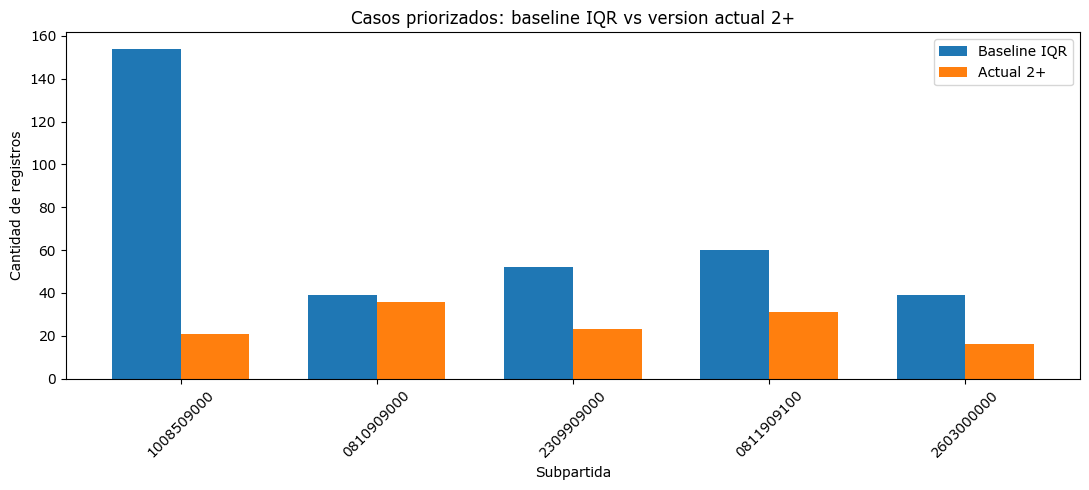

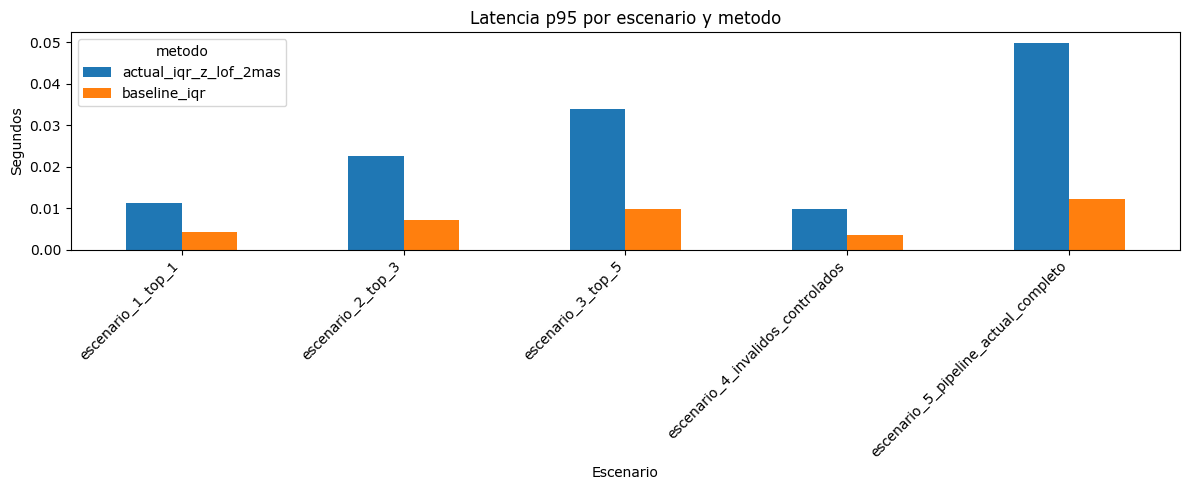

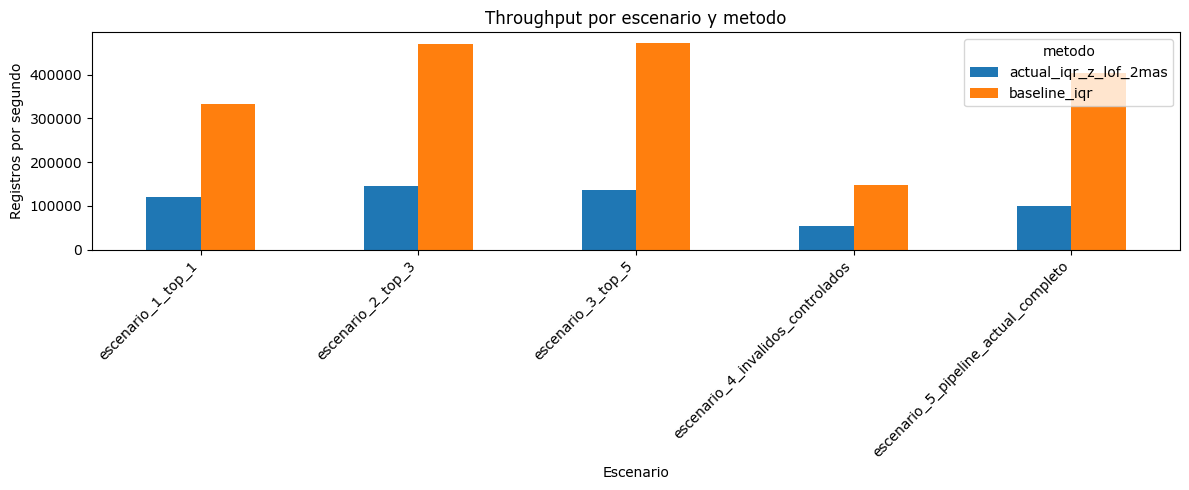

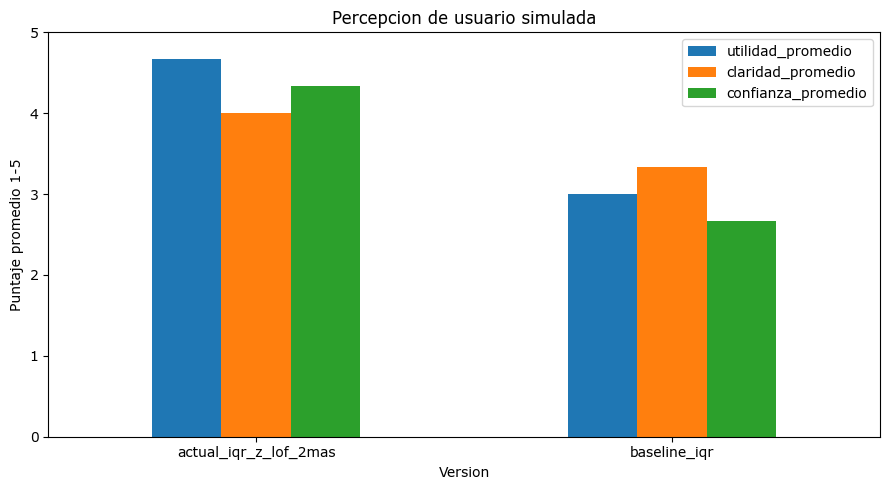

Figuras generadas:
artifacts_sprint5_comparativo_latencia\figuras\outliers_baseline_vs_actual.png
artifacts_sprint5_comparativo_latencia\figuras\latencia_p50_p95_por_escenario.png
artifacts_sprint5_comparativo_latencia\figuras\throughput_por_escenario.png
artifacts_sprint5_comparativo_latencia\figuras\percepcion_usuario_simulada.png


In [14]:
# =============================================================================
# 14. FIGURAS
# =============================================================================

def guardar_figura_outliers_baseline_actual(tabla: pd.DataFrame) -> Path:
    """
    Genera figura de outliers baseline vs actual por subpartida.

    Parameters
    ----------
    tabla : pd.DataFrame
        Tabla comparativa baseline vs actual.

    Returns
    -------
    Path
        Ruta de la figura generada.
    """
    ruta = FIGURES_DIR / "outliers_baseline_vs_actual.png"
    x = np.arange(len(tabla))
    ancho = 0.35

    plt.figure(figsize=(11, 5))
    plt.bar(x - ancho / 2, tabla["baseline_iqr_casos"], width=ancho, label="Baseline IQR")
    plt.bar(x + ancho / 2, tabla["actual_2_mas_casos"], width=ancho, label="Actual 2+")
    plt.xticks(x, tabla[COL_SUBPARTIDA], rotation=45)
    plt.title("Casos priorizados: baseline IQR vs version actual 2+")
    plt.xlabel("Subpartida")
    plt.ylabel("Cantidad de registros")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    plt.show()
    return ruta


def guardar_figura_latencia(tabla: pd.DataFrame) -> Path:
    """
    Genera figura de p50 y p95 por escenario.

    Parameters
    ----------
    tabla : pd.DataFrame
        Tabla de latencia.

    Returns
    -------
    Path
        Ruta de la figura generada.
    """
    ruta = FIGURES_DIR / "latencia_p50_p95_por_escenario.png"
    pivot = tabla.pivot_table(
        index="escenario",
        columns="metodo",
        values="p95_segundos",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(12, 5))
    plt.title("Latencia p95 por escenario y metodo")
    plt.xlabel("Escenario")
    plt.ylabel("Segundos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    plt.show()
    return ruta


def guardar_figura_throughput(tabla: pd.DataFrame) -> Path:
    """
    Genera figura de throughput por escenario.

    Parameters
    ----------
    tabla : pd.DataFrame
        Tabla de latencia.

    Returns
    -------
    Path
        Ruta de la figura generada.
    """
    ruta = FIGURES_DIR / "throughput_por_escenario.png"
    pivot = tabla.pivot_table(
        index="escenario",
        columns="metodo",
        values="throughput_registros_segundo",
        aggfunc="mean",
    )

    pivot.plot(kind="bar", figsize=(12, 5))
    plt.title("Throughput por escenario y metodo")
    plt.xlabel("Escenario")
    plt.ylabel("Registros por segundo")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    plt.show()
    return ruta


def guardar_figura_feedback(tabla: pd.DataFrame) -> Path:
    """
    Genera figura de percepcion simulada por version.

    Parameters
    ----------
    tabla : pd.DataFrame
        Resumen de feedback simulado.

    Returns
    -------
    Path
        Ruta de la figura generada.
    """
    ruta = FIGURES_DIR / "percepcion_usuario_simulada.png"
    columnas = ["utilidad_promedio", "claridad_promedio", "confianza_promedio"]
    tabla_plot = tabla.set_index("version")[columnas]

    tabla_plot.plot(kind="bar", figsize=(9, 5))
    plt.title("Percepcion de usuario simulada")
    plt.xlabel("Version")
    plt.ylabel("Puntaje promedio 1-5")
    plt.ylim(0, 5)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150)
    plt.show()
    return ruta


figura_outliers = guardar_figura_outliers_baseline_actual(tabla_comparativo)
figura_latencia = guardar_figura_latencia(tabla_latencia)
figura_throughput = guardar_figura_throughput(tabla_latencia)
figura_feedback = guardar_figura_feedback(resumen_feedback_usuario)

print("Figuras generadas:")
print(figura_outliers)
print(figura_latencia)
print(figura_throughput)
print(figura_feedback)

## 15. Hallazgos

Esta seccion resume que funciona, que no funciona y por que. Se actualiza automaticamente con las tablas calculadas.


In [15]:
# =============================================================================
# 15. HALLAZGOS
# =============================================================================

def construir_hallazgos(
    tabla_comparativo_local: pd.DataFrame,
    tabla_latencia_local: pd.DataFrame,
    resumen_feedback_local: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye tabla de hallazgos para exposicion.

    Parameters
    ----------
    tabla_comparativo_local : pd.DataFrame
        Comparativo baseline vs actual.
    tabla_latencia_local : pd.DataFrame
        Resultados de latencia.
    resumen_feedback_local : pd.DataFrame
        Resumen de percepcion simulada.

    Returns
    -------
    pd.DataFrame
        Tabla de hallazgos.
    """
    p95_actual = tabla_latencia_local.loc[
        tabla_latencia_local["metodo"].eq("actual_iqr_z_lof_2mas"),
        "p95_segundos",
    ].max()

    errores_actual = tabla_latencia_local.loc[
        tabla_latencia_local["metodo"].eq("actual_iqr_z_lof_2mas"),
        "errores",
    ].sum()

    utilidad_actual = resumen_feedback_local.loc[
        resumen_feedback_local["version"].eq("actual_iqr_z_lof_2mas"),
        "utilidad_promedio",
    ].iloc[0]

    casos_baseline = int(tabla_comparativo_local["baseline_iqr_casos"].sum())
    casos_actual = int(tabla_comparativo_local["actual_2_mas_casos"].sum())

    hallazgos = [
        {
            "tipo": "funciona",
            "hallazgo": "Tratar cada subpartida como slice independiente permite comparar distribuciones propias de V.U.",
            "evidencia": f"Se analizaron {tabla_comparativo_local[COL_SUBPARTIDA].nunique()} subpartidas top por movimiento.",
        },
        {
            "tipo": "funciona",
            "hallazgo": "La coincidencia 2+ mejora la priorizacion frente a usar solo IQR.",
            "evidencia": f"Baseline IQR marca {casos_baseline:,} casos; version actual prioriza {casos_actual:,} casos con evidencia convergente.",
        },
        {
            "tipo": "no_funciona_totalmente",
            "hallazgo": "Usar solo IQR puede sobredetectar extremos en distribuciones asimetricas.",
            "evidencia": "Se observa discrepancia entre IQR, z-score y LOF en algunos slices.",
        },
        {
            "tipo": "costo_tecnico",
            "hallazgo": "LOF aporta deteccion local, pero aumenta la latencia frente a IQR.",
            "evidencia": f"p95 maximo version actual: {p95_actual:.4f} segundos; errores: {errores_actual}.",
        },
        {
            "tipo": "usuario",
            "hallazgo": "La version actual aumenta utilidad y confianza en la prueba guiada simulada.",
            "evidencia": f"Utilidad simulada promedio version actual: {utilidad_actual:.2f}/5.",
        },
    ]

    return pd.DataFrame(hallazgos)


tabla_hallazgos = construir_hallazgos(tabla_comparativo, tabla_latencia, resumen_feedback_usuario)
tabla_hallazgos

,tipo,hallazgo,evidencia
0,funciona,Tratar cada subpartida como slice independient...,Se analizaron 5 subpartidas top por movimiento.
1,funciona,La coincidencia 2+ mejora la priorizacion fren...,Baseline IQR marca 344 casos; version actual p...
2,no_funciona_totalmente,Usar solo IQR puede sobredetectar extremos en ...,"Se observa discrepancia entre IQR, z-score y L..."
3,costo_tecnico,"LOF aporta deteccion local, pero aumenta la la...",p95 maximo version actual: 0.0499 segundos; er...
4,usuario,La version actual aumenta utilidad y confianza...,Utilidad simulada promedio version actual: 4.6...


## 16. Proximos pasos: A/B, canary y backlog

- **A/B:** comparar baseline IQR vs version actual en las mismas subpartidas, con el mismo periodo, mismas reglas y mismos criterios de aceptacion.
- **Canary:** aplicar la version actual primero a un porcentaje pequeno de subpartidas o a las subpartidas top, sin afectar decisiones reales.
- **Backlog:** lista priorizada de mejoras tecnicas y de negocio.


In [16]:
# =============================================================================
# 16. PROXIMOS PASOS
# =============================================================================

tabla_proximos_pasos = pd.DataFrame([
    {
        "prioridad": 1,
        "tipo": "A/B",
        "accion": "Comparar baseline IQR vs version actual IQR+z-score+LOF en el mismo periodo y top 5 subpartidas.",
        "criterio_aceptacion": "Mayor utilidad percibida, menor ruido operativo y p95 dentro del SLO.",
    },
    {
        "prioridad": 2,
        "tipo": "Canary",
        "accion": "Ejecutar version actual solo en subpartidas priorizadas antes de generalizar.",
        "criterio_aceptacion": "Errores menores al SLO y revision manual viable.",
    },
    {
        "prioridad": 3,
        "tipo": "Backlog",
        "accion": "Incorporar pais, operador, calidad y unidad fisica para explicar heterogeneidad del V.U.",
        "criterio_aceptacion": "Causas probables mas trazables por slice.",
    },
    {
        "prioridad": 4,
        "tipo": "Backlog",
        "accion": "Crear detalle explicable por registro: metodo que marca, limite IQR, z-score y score LOF.",
        "criterio_aceptacion": "Usuario entiende por que un registro fue priorizado.",
    },
    {
        "prioridad": 5,
        "tipo": "Backlog",
        "accion": "Monitorear drift de distribucion del V.U. por subpartida y periodo.",
        "criterio_aceptacion": "Alertas cuando cambie la distribucion o el porcentaje de outliers.",
    },
])

tabla_proximos_pasos

,prioridad,tipo,accion,criterio_aceptacion
0,1,A/B,Comparar baseline IQR vs version actual IQR+z-...,"Mayor utilidad percibida, menor ruido operativ..."
1,2,Canary,Ejecutar version actual solo en subpartidas pr...,Errores menores al SLO y revision manual viable.
2,3,Backlog,"Incorporar pais, operador, calidad y unidad fi...",Causas probables mas trazables por slice.
3,4,Backlog,Crear detalle explicable por registro: metodo ...,Usuario entiende por que un registro fue prior...
4,5,Backlog,Monitorear drift de distribucion del V.U. por ...,Alertas cuando cambie la distribucion o el por...


## 17. Tabla final para exposicion

Esta tabla responde directamente al entregable: objetivo y KPI, setup, resultados tecnicos, percepcion simulada, hallazgos y recomendacion de despliegue minimo.


In [17]:
# =============================================================================
# 17. TABLA FINAL PARA EXPOSICION
# =============================================================================

def construir_tabla_final_exposicion() -> pd.DataFrame:
    """
    Construye la tabla final del avance semanal.

    Parameters
    ----------
    None
        Usa tablas globales ya calculadas.

    Returns
    -------
    pd.DataFrame
        Tabla resumen lista para exposicion.
    """
    lat_actual = tabla_latencia[tabla_latencia["metodo"].eq("actual_iqr_z_lof_2mas")]
    feedback_actual = resumen_feedback_usuario[resumen_feedback_usuario["version"].eq("actual_iqr_z_lof_2mas")].iloc[0]
    top_subpartidas = ", ".join(tabla_top_subpartidas[COL_SUBPARTIDA].astype(str).tolist())

    p50 = float(lat_actual["p50_segundos"].median())
    p95 = float(lat_actual["p95_segundos"].max())
    throughput = float(lat_actual["throughput_registros_segundo"].median())
    errores = int(lat_actual["errores"].sum())

    if p95 <= SLO_P95_SEGUNDOS and errores == 0:
        recomendacion = "Despliegue minimo tipo canary sobre top subpartidas, manteniendo monitoreo y rollback."
    else:
        recomendacion = "No desplegar aun; optimizar LOF, reducir columnas o usarlo como segunda etapa."

    return pd.DataFrame([
        {
            "objetivo": "Comparar baseline vs version actual para priorizar valores unitarios anomalos.",
            "kpi_negocio": "Reducir esfuerzo de revision manual priorizando casos con evidencia estadistica convergente.",
            "baseline": "IQR por subpartida sobre V.U.",
            "version_actual": "IQR + LOF + z-score con coincidencia 2+.",
            "top_5_subpartidas": top_subpartidas,
            "metrica_tecnica": "Casos priorizados 2+, discrepancia entre metodos, IC mediana, CV y score de slice.",
            "latencia_p50_segundos": p50,
            "latencia_p95_segundos": p95,
            "throughput_registros_segundo": throughput,
            "errores": errores,
            "percepcion_simulada": (
                f"Utilidad {feedback_actual['utilidad_promedio']:.2f}/5; "
                f"claridad {feedback_actual['claridad_promedio']:.2f}/5; "
                f"confianza {feedback_actual['confianza_promedio']:.2f}/5."
            ),
            "conclusion": "La version actual mejora la priorizacion al exigir evidencia convergente, pero LOF debe controlarse por latencia.",
            "recomendacion_despliegue_minimo": recomendacion,
        }
    ])


tabla_final_exposicion = construir_tabla_final_exposicion()
tabla_final_exposicion

,objetivo,kpi_negocio,baseline,version_actual,top_5_subpartidas,metrica_tecnica,latencia_p50_segundos,latencia_p95_segundos,throughput_registros_segundo,errores,percepcion_simulada,conclusion,recomendacion_despliegue_minimo
0,Comparar baseline vs version actual para prior...,Reducir esfuerzo de revision manual priorizand...,IQR por subpartida sobre V.U.,IQR + LOF + z-score con coincidencia 2+.,"1008509000, 0810909000, 0811909100, 2309909000...","Casos priorizados 2+, discrepancia entre metod...",0.022325,0.049884,120806.622273,0,Utilidad 4.67/5; claridad 4.00/5; confianza 4....,La version actual mejora la priorizacion al ex...,Despliegue minimo tipo canary sobre top subpar...


## 18. Exportacion de evidencias

Se exportan scripts de evidencia en formato CSV/TXT con delimitador `|` y sin acentos.


In [18]:
# =============================================================================
# 18. EXPORTACION DE EVIDENCIAS
# =============================================================================

exportar_csv_pipe(resumen_validacion, ARTIFACTS_DIR / "resumen_validacion.csv")
exportar_csv_pipe(tabla_top_subpartidas, ARTIFACTS_DIR / "top_5_subpartidas.csv")
exportar_csv_pipe(tabla_metricas_slice, ARTIFACTS_DIR / "metricas_por_slice.csv")
exportar_csv_pipe(tabla_slices_problematicos, ARTIFACTS_DIR / "slices_problematicos.csv")
exportar_csv_pipe(tabla_comparativo, ARTIFACTS_DIR / "comparativo_baseline_actual.csv")
exportar_csv_pipe(tabla_latencia, ARTIFACTS_DIR / "latencia_p50_p95_throughput.csv")
exportar_csv_pipe(tabla_latencia_etapas, ARTIFACTS_DIR / "latencia_por_etapa.csv")
exportar_csv_pipe(tabla_optimizaciones, ARTIFACTS_DIR / "optimizaciones_probadas.csv")
exportar_csv_pipe(tabla_feedback_usuario, ARTIFACTS_DIR / "feedback_usuario_simulado_detalle.csv")
exportar_csv_pipe(resumen_feedback_usuario, ARTIFACTS_DIR / "feedback_usuario_simulado_resumen.csv")
exportar_csv_pipe(tabla_hallazgos, ARTIFACTS_DIR / "hallazgos.csv")
exportar_csv_pipe(tabla_proximos_pasos, ARTIFACTS_DIR / "proximos_pasos.csv")
exportar_csv_pipe(tabla_final_exposicion, ARTIFACTS_DIR / "tabla_final_exposicion.csv")

readme = f"""
SPRINT 5 - COMPARATIVO BASELINE VS ACTUAL Y LATENCIA
Fecha de ejecucion: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Modo de carga: {MODO_CARGA}
Periodo: {FEC_INI} a {FEC_FIN}
Seed: {SEED}
Baseline: IQR por subpartida sobre V.U.
Version actual: IQR + z-score + LOF con coincidencia 2+.
Top subpartidas: {', '.join(tabla_top_subpartidas[COL_SUBPARTIDA].astype(str).tolist())}
SLO propuesto: p95 <= {SLO_P95_SEGUNDOS} segundos, error <= {SLO_ERROR_MAX_PCT}%.
Observacion: la percepcion de usuario es simulada para exposicion, no feedback real.
Archivos exportados con delimitador pipe.
"""

exportar_txt_sin_acentos(readme, ARTIFACTS_DIR / "README_REPRODUCIBILIDAD.txt")

print("Evidencias exportadas en:")
print(ARTIFACTS_DIR.resolve())
print("Archivos principales:")
for ruta in sorted(ARTIFACTS_DIR.glob("*.csv")):
    print("-", ruta.name)
print("- README_REPRODUCIBILIDAD.txt")

Evidencias exportadas en:
C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\06_Sprint5\artifacts_sprint5_comparativo_latencia
Archivos principales:
- comparativo_baseline_actual.csv
- feedback_usuario_simulado_detalle.csv
- feedback_usuario_simulado_resumen.csv
- hallazgos.csv
- latencia_p50_p95_throughput.csv
- latencia_por_etapa.csv
- metricas_por_slice.csv
- optimizaciones_probadas.csv
- proximos_pasos.csv
- resumen_validacion.csv
- slices_problematicos.csv
- tabla_final_exposicion.csv
- top_5_subpartidas.csv
- README_REPRODUCIBILIDAD.txt


## 19. Cierre para exposicion

La conclusion del avance es que la version actual no busca reemplazar la revision humana, sino **priorizar mejor** los casos de valor unitario anomalo. El baseline IQR es simple e interpretable, pero puede generar ruido cuando la distribucion del V.U. es asimetrica. La version actual agrega z-score y LOF, y prioriza coincidencias 2+, lo que mejora la confianza de revision. El costo tecnico principal es la latencia de LOF; por eso el siguiente paso recomendado es un canary sobre subpartidas priorizadas, con monitoreo de p95, errores y utilidad percibida.
